In [1]:
import csv
import json
import matplotlib.pyplot as plt
import numpy as np

N_ITER = 20  # Number of intended iterations

def analyze_results(csv_file):
    final_hypervolumes = []
    total_runtimes = []
    oom_runs = []

    with open(csv_file, mode="r") as file:
        reader = csv.DictReader(file)
        for row in reader:
            run_id = row["run_id"]
            hvs = json.loads(row["hypervolumes"])
            times = json.loads(row["times"])

            final_hv = hvs[-1]
            total_time = sum(times)
            final_hypervolumes.append(final_hv)
            total_runtimes.append(total_time)

            iterations_completed = len(hvs) - 1
            if iterations_completed < N_ITER:
                oom_runs.append((run_id, iterations_completed))

            oom_tag = f"[OOM at iter {iterations_completed}]" if iterations_completed < N_ITER else ""
            print(f"Run {run_id}: Final HV = {final_hv:.5f}, Total Runtime = {total_time:.2f} s {oom_tag}")

    avg_hv = sum(final_hypervolumes) / len(final_hypervolumes)
    avg_time = sum(total_runtimes) / len(total_runtimes)

    print("\n--- Summary ---")
    print(f"Average Final Hypervolume: {avg_hv:.5f}")
    print(f"Average Total Runtime: {avg_time:.2f} s")
    if oom_runs:
        print("OOM Errors:")
        for run_id, iter_num in oom_runs:
            print(f" - Run {run_id}: OOM at iteration {iter_num}/{N_ITER}")
    else:
        print("No OOM errors encountered.")

def plot_hypervolume_progression(csv_file):
    plt.figure(figsize=(10, 6))
    
    with open(csv_file, mode="r") as file:
        reader = csv.DictReader(file)
        for row in reader:
            run_id = row["run_id"]
            hvs = json.loads(row["hypervolumes"])

            iterations_completed = len(hvs) - 1
            iterations = list(range(len(hvs)))

            # Plot each run with a dashed line if OOM occurred
            if iterations_completed < N_ITER:
                plt.plot(iterations, hvs, label=f"Run {run_id} (OOM at iter {iterations_completed})", linestyle="--", marker = 'o', alpha=0.7)
            else:
                plt.plot(iterations, hvs, label=f"Run {run_id}", linestyle = '-', marker = 'o', alpha=0.7)

    plt.xlabel("Iteration")
    plt.ylabel("Hypervolume")
    plt.title("Hypervolume Progression per Run")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize="small")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def get_hv_uncertainty(csv_file):
    all_hvs = []

    with open(csv_file, mode="r") as file:
        reader = csv.DictReader(file)
        for row in reader:
            hvs = json.loads(row["hypervolumes"])
            # Pad with last value if run ended early due to OOM
            if len(hvs) < N_ITER + 1:
                hvs += [hvs[-1]] * (N_ITER + 1 - len(hvs))
            all_hvs.append(hvs)

    all_hvs = np.array(all_hvs)
    iterations = np.arange(N_ITER + 1)

    mean_hv = np.mean(all_hvs, axis=0)
    std_hv = np.std(all_hvs, axis=0)
    return mean_hv, std_hv, iterations

def compare_hv_with_uncertainty(path):
    plt.figure(figsize=(10, 6))
    mean_joint, std_joint, iter_joint = get_hv_uncertainty(path + '.csv')
    mean_seq, std_seq, iter_seq = get_hv_uncertainty(path + '_sequential.csv')

    plt.plot(iter_joint, mean_joint, label="Joint Mean", color="blue", linewidth=2)
    plt.fill_between(iter_joint, mean_joint - std_joint, mean_joint + std_joint, color="blue", alpha=0.3, label="±1 Std. Dev.")

    plt.plot(iter_seq, mean_seq, label="Sequential Mean", color="red", linewidth=2)
    plt.fill_between(iter_seq, mean_seq - std_seq, mean_seq + std_seq, color="red", alpha=0.3, label="±1 Std. Dev.")

    plt.xlabel("Iteration")
    plt.xticks(np.arange(len(iter_seq)))
    plt.ylabel("Hypervolume")
    plt.title("Hypervolume Progression with Uncertainty")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

Run 1: Final HV = 125.75683, Total Runtime = 779.33 s [OOM at iter 9]
Run 2: Final HV = 114.75353, Total Runtime = 826.30 s [OOM at iter 8]
Run 3: Final HV = 126.42440, Total Runtime = 1130.47 s [OOM at iter 12]
Run 4: Final HV = 128.02963, Total Runtime = 1268.34 s [OOM at iter 14]
Run 5: Final HV = 128.03542, Total Runtime = 1025.62 s [OOM at iter 12]
Run 6: Final HV = 126.02357, Total Runtime = 889.01 s [OOM at iter 8]
Run 7: Final HV = 128.62256, Total Runtime = 1535.95 s [OOM at iter 15]
Run 8: Final HV = 126.21204, Total Runtime = 902.73 s [OOM at iter 12]
Run 9: Final HV = 128.02917, Total Runtime = 1197.14 s [OOM at iter 11]
Run 10: Final HV = 114.68304, Total Runtime = 659.33 s [OOM at iter 9]

--- Summary ---
Average Final Hypervolume: 124.65702
Average Total Runtime: 1021.42 s
OOM Errors:
 - Run 1: OOM at iteration 9/20
 - Run 2: OOM at iteration 8/20
 - Run 3: OOM at iteration 12/20
 - Run 4: OOM at iteration 14/20
 - Run 5: OOM at iteration 12/20
 - Run 6: OOM at iteration

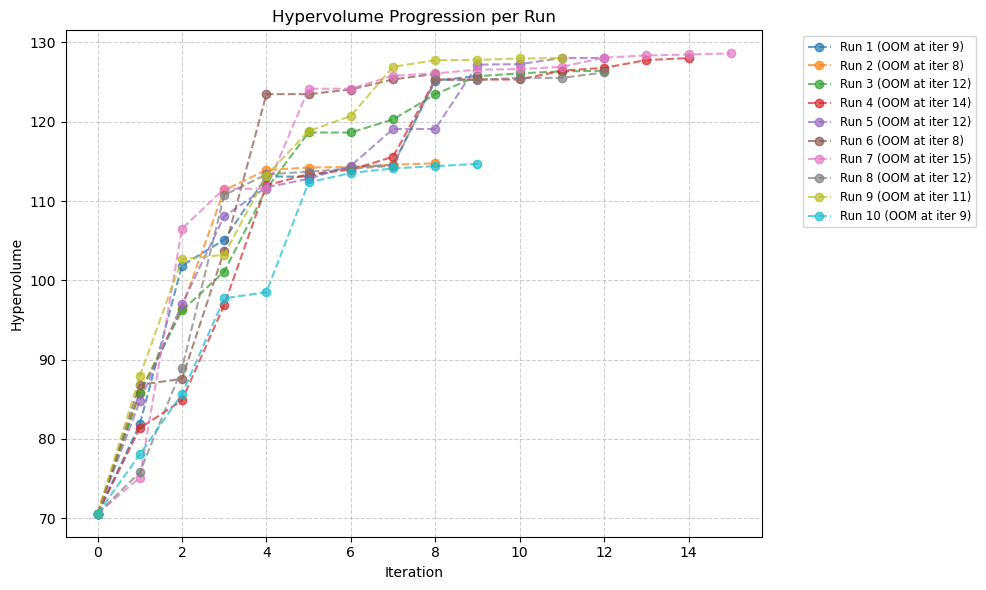

In [2]:
fname = "results/bo_replicability_results.csv"
analyze_results(fname)
plot_hypervolume_progression(fname)

Run 1: Final HV = 115.88862, Total Runtime = 1182.82 s 
Run 2: Final HV = 129.64564, Total Runtime = 761.44 s 
Run 3: Final HV = 115.87477, Total Runtime = 988.30 s 
Run 4: Final HV = 115.88174, Total Runtime = 1056.50 s 
Run 5: Final HV = 115.88521, Total Runtime = 1082.75 s 
Run 6: Final HV = 115.88658, Total Runtime = 1060.37 s 
Run 7: Final HV = 115.88994, Total Runtime = 1083.90 s 
Run 8: Final HV = 129.63511, Total Runtime = 791.81 s 
Run 9: Final HV = 115.88569, Total Runtime = 1098.52 s 
Run 10: Final HV = 129.60861, Total Runtime = 870.26 s 

--- Summary ---
Average Final Hypervolume: 120.00819
Average Total Runtime: 997.67 s
No OOM errors encountered.


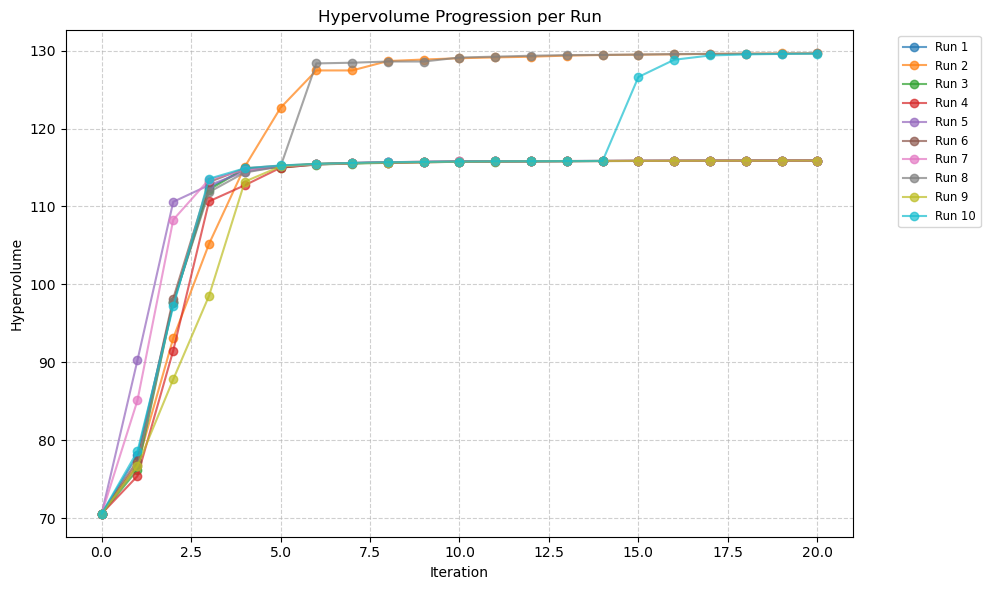

In [3]:
fname = "results/bo_replicability_results_sequential.csv"
analyze_results(fname)
plot_hypervolume_progression(fname)

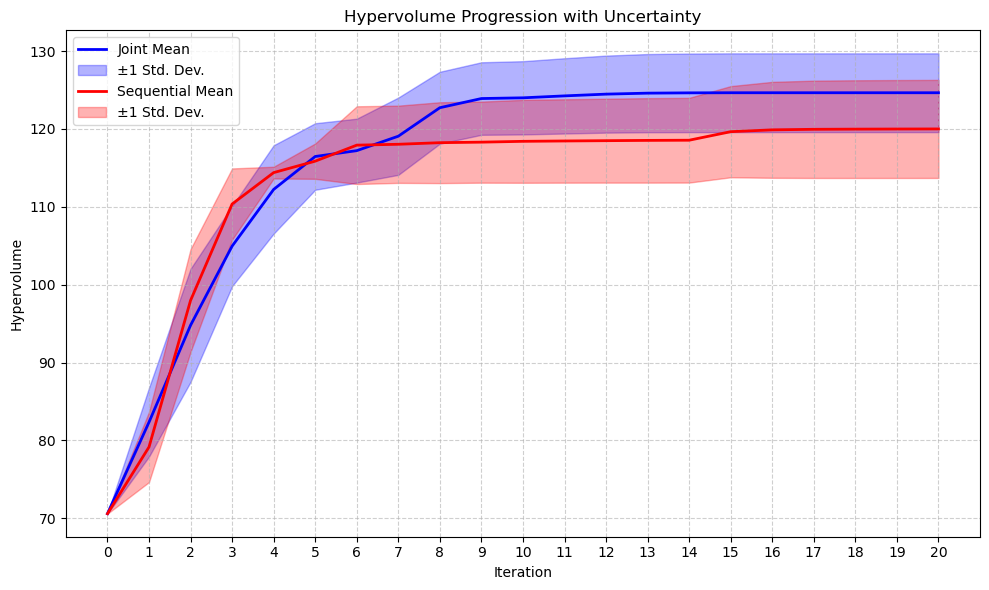

In [4]:
compare_hv_with_uncertainty('results/bo_replicability_results')

In [11]:
import torch
import io
import pickle

class CPU_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        else:
            return super().find_class(module, name)

In [10]:
import torch
import os
import pickle
from botorch.utils.multi_objective.box_decompositions import NondominatedPartitioning
from matplotlib import animation

# --- Load Functions (with CPU mapping) ---
fname = 'data64/func1.pkl'
func1 = torch.load(fname, map_location=torch.device('cpu'), pickle_module=pickle)
with open('data64/func2.pkl', 'rb') as file:
    func2 = torch.load(file, map_location='cpu', pickle_module=pickle)


# from botorch.utils.multi_objective.box_decompositions.non_dominated import FastNondominatedPartitioning
# from botorch.utils.multi_objective.box_decompositions.dominated import DominatedPartitioning

N_ITER = 20  # Number of intended iterations
REFERENCE = torch.tensor([-1, -1])
GIF_FILE = "pareto_progression.gif"

def create_pareto_gif(csv_file, run_id):
    with open(csv_file, mode="r") as file:
        reader = csv.DictReader(file)
        candidates_list = None
        for row in reader:
            if int(row["run_id"]) == run_id:
                candidates_list = json.loads(row["candidates"])
                break

    if candidates_list is None:
        print(f"Run {run_id} not found in {csv_file}.")
        return

    fig, ax = plt.subplots(figsize=(8, 6))
    previous_candidates = []

    def update(frame):
        ax.clear()

        # Load and evaluate candidates
        candidates = torch.tensor(candidates_list[frame])
        obj1_values = func1(candidates).detach().numpy()
        obj2_values = func2(candidates).detach().numpy()
        current_points = np.vstack((obj1_values, obj2_values)).T
        previous_candidates.append(current_points)

        # Plot all previous candidates with lower alpha
        for past_points in previous_candidates[:-1]:
            ax.scatter(past_points[:, 0], past_points[:, 1], c="grey", alpha=0.2, label="Previous Candidates" if frame == 0 else "")

        # Plot current candidates
        ax.scatter(current_points[:, 0], current_points[:, 1], c="blue", alpha=0.6, label="Current Candidates")

        # Plot Pareto front
        partitioning = NondominatedPartitioning(ref_point=REFERENCE, Y=torch.tensor(current_points))
        pareto_front = partitioning.pareto_Y.cpu().numpy()
        ax.scatter(pareto_front[:, 0], pareto_front[:, 1], c="red", label="Pareto Front")

        ax.set_title(f"Pareto Frontier - Iteration {frame}")
        ax.set_xlabel("Objective 1")
        ax.set_ylabel("Objective 2")
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.grid(True, linestyle='--', alpha=0.5)

        # Prevent duplicate legends
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys())

    anim = animation.FuncAnimation(fig, update, frames=len(candidates_list), repeat=False)
    anim.save(GIF_FILE, writer='pillow', fps=2)
    plt.close()
    print(f"GIF saved as {GIF_FILE}")

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.